# 10.1. 가리움과 유효 핵전하

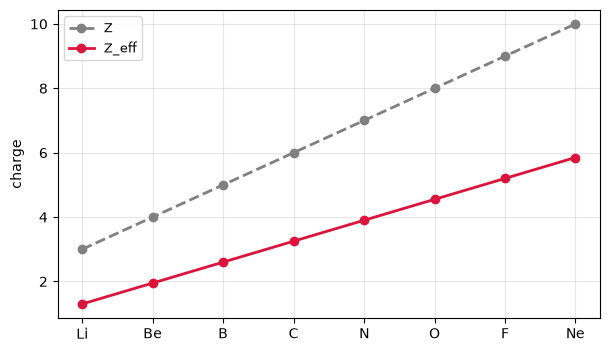

 Li: Z =  3,  S = 1.70,  Z_eff = 1.30
 Be: Z =  4,  S = 2.05,  Z_eff = 1.95
  B: Z =  5,  S = 2.40,  Z_eff = 2.60
  C: Z =  6,  S = 2.75,  Z_eff = 3.25
  N: Z =  7,  S = 3.10,  Z_eff = 3.90
  O: Z =  8,  S = 3.45,  Z_eff = 4.55
  F: Z =  9,  S = 3.80,  Z_eff = 5.20
 Ne: Z = 10,  S = 4.15,  Z_eff = 5.85


In [2]:
import numpy as np
import matplotlib.pyplot as plt

names = ["Li", "Be", "B", "C", "N", "O", "F", "Ne"]
Z = np.arange(3, 11)
S = np.array([1.70, 2.05, 2.40, 2.75, 3.10, 3.45, 3.80, 4.15])
Zeff = Z - S

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Z, Z, "o--", color="gray", lw=2, label="Z")
ax.plot(Z, Zeff, "o-", color="crimson", lw=2, label="Z_eff")
ax.set_xticks(Z)
ax.set_xticklabels(names)
ax.set_ylabel("charge")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.show()

for n, z, s in zip(names, Z, S):
    print(f"{n:>3}: Z = {z:2d},  S = {s:.2f},  Z_eff = {z-s:.2f}")

In [8]:
Eh = 27.2114


def total_energy(shells):
    """shells: (n, Z_eff, 전자 수) 목록. 원자 단위로 전체 에너지를 더한다"""
    return sum(cnt * (-(z**2) / (2 * n**2)) for n, z, cnt in shells)


# (원소, 중성 원자, 양이온, 실측 IE)
cases = [
    ("He", [(1, 1.70, 2)], [(1, 2.00, 1)], 24.59),
    ("Li", [(1, 2.70, 2), (2, 1.30, 1)], [(1, 2.70, 2)], 5.39),
    ("C", [(1, 5.70, 2), (2, 3.25, 4)], [(1, 5.70, 2), (2, 3.60, 3)], 11.26),
    ("Ne", [(1, 9.70, 2), (2, 5.85, 8)], [(1, 9.70, 2), (2, 6.20, 7)], 21.56),
]

print(f"{'원소':>3} {'어림':>7} {'실측':>7} {'오차':>6}")
for name, atom, ion, ie_exp in cases:
    ie = (total_energy(ion) - total_energy(atom)) * Eh
    print(f"{name:>4} {ie:9.2f} {ie_exp:8.2f} {(ie - ie_exp) / ie_exp:+7.1%}")

 원소      어림      실측     오차
  He     24.22    24.59   -1.5%
  Li      5.75     5.39   +6.6%
   C     11.46    11.26   +1.8%
  Ne     15.99    21.56  -25.9%
